# Random walk con moneda

Esta notebook:
1. Genera una serie temporal tipo *random walk* a partir de tiradas de moneda (±1).
2. Ajusta un modelo ARIMA (statsmodels).
3. Evalúa pronósticos fuera de muestra y los compara con un baseline ingenuo.

Idea clave: si el proceso es un random walk puro, los incrementos son ruido blanco y el mejor pronóstico (bajo MSE) para el siguiente paso es **el último valor observado**. ARIMA no puede “adivinar” las próximas tiradas de moneda.


In [1]:
# Si falta statsmodels, descomenta la siguiente línea:
# !pip -q install statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)


## 1) Generar random walk desde tiradas de moneda

Cada tirada produce un incremento `+1` (cara) o `-1` (cruz). La serie es la suma acumulada.


In [2]:
n = 1500  # longitud

# Tiradas de moneda: +1 / -1
steps = np.where(np.random.rand(n) < 0.5, -1, 1)

# Random walk
y = steps.cumsum().astype(float)
t = pd.date_range('2020-01-01', periods=n, freq='D')
s = pd.Series(y, index=t, name='random_walk')

s.head(), s.tail()

(2020-01-01   -1.0
 2020-01-02    0.0
 2020-01-03    1.0
 2020-01-04    2.0
 2020-01-05    1.0
 Freq: D, Name: random_walk, dtype: float64,
 2024-02-04    18.0
 2024-02-05    19.0
 2024-02-06    18.0
 2024-02-07    17.0
 2024-02-08    18.0
 Freq: D, Name: random_walk, dtype: float64)

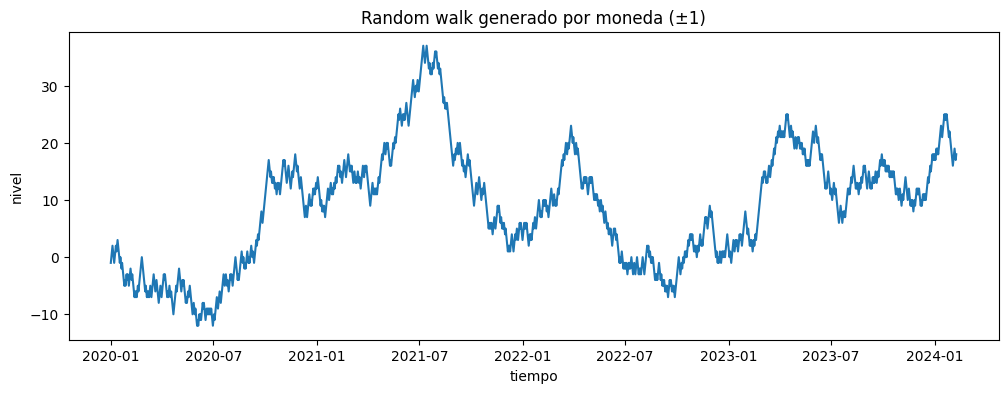

In [3]:
plt.figure(figsize=(12,4))
plt.plot(s)
plt.title('Random walk generado por moneda (±1)')
plt.xlabel('tiempo')
plt.ylabel('nivel')
plt.show()


## 2) Estacionariedad: nivel vs diferencias

Un random walk **no es estacionario** en nivel. Sin embargo, sus **diferencias de primer orden** (los incrementos) sí son estacionarias: deberían parecer ruido blanco.


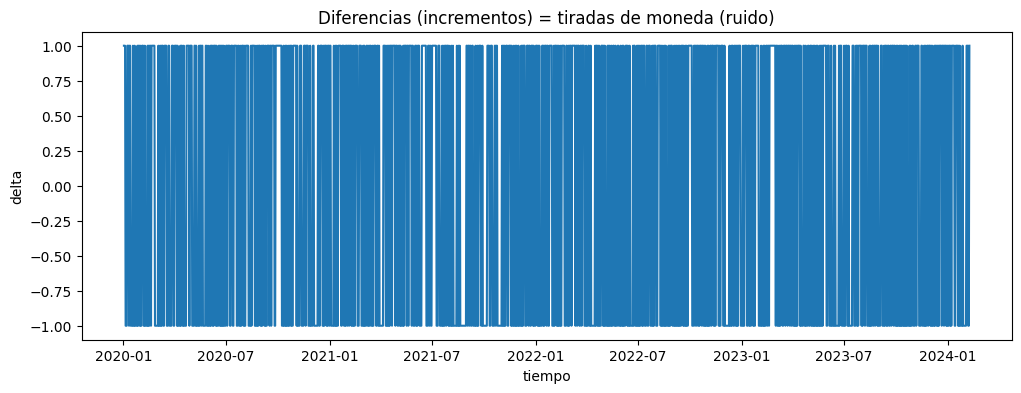

ADF nivel: statistic=-1.937, p-value=0.315
ADF diferencias: statistic=-38.943, p-value=0


In [4]:
dy = s.diff().dropna()  # diferencias (los pasos)

plt.figure(figsize=(12,4))
plt.plot(dy)
plt.title('Diferencias (incrementos) = tiradas de moneda (ruido)')
plt.xlabel('tiempo')
plt.ylabel('delta')
plt.show()

def adf_report(x, name):
    stat, pvalue, *_ = adfuller(x, autolag='AIC')
    print(f"ADF {name}: statistic={stat:.3f}, p-value={pvalue:.3g}")

adf_report(s.values, 'nivel')
adf_report(dy.values, 'diferencias')


## 3) Setup de evaluación (train/test) y baselines

Para un random walk, el baseline natural a 1 paso es:
- **Naive (random-walk forecast):** $ \hat y_{t+1} = y_t $

Ese baseline es óptimo bajo MSE para un random walk puro. Si ARIMA está “bien”, no debería mejorar esto de manera consistente.


In [5]:
h = 300  # tamaño del test
train = s.iloc[:-h]
test = s.iloc[-h:]

naive_pred = test.shift(1)  # yhat_{t} = y_{t-1}
naive_pred.iloc[0] = train.iloc[-1]

def metrics(y_true, y_pred):
    err = (y_true - y_pred)
    mse = float(np.mean(err**2))
    mae = float(np.mean(np.abs(err)))
    return mse, mae

mse_naive, mae_naive = metrics(test.values, naive_pred.values)
mse_naive, mae_naive

(1.0, 1.0)

## 4) Ajustar ARIMA y pronosticar fuera de muestra

Para un random walk, un modelo típico equivalente es **ARIMA(0,1,0)** (random walk). También probaremos algún ARIMA más "flexible" (por ejemplo ARIMA(1,1,1)) para mostrar que no logra magia.


In [6]:
def fit_forecast_arima(order):
    model = ARIMA(train, order=order)
    res = model.fit()
    fc = res.forecast(steps=h)
    fc.index = test.index
    return res, fc

orders = [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]
results = {}

for order in orders:
    res, fc = fit_forecast_arima(order)
    mse, mae = metrics(test.values, fc.values)
    results[order] = {'res': res, 'fc': fc, 'mse': mse, 'mae': mae, 'aic': res.aic}

pd.DataFrame(
    {str(k): {'AIC': v['aic'], 'MSE_test': v['mse'], 'MAE_test': v['mae']} for k,v in results.items()}
).T.sort_values('MSE_test')


,AIC,MSE_test,MAE_test
"(0, 1, 1)",3406.275329,99.923016,9.017124
"(1, 1, 0)",3406.280666,99.927791,9.017373
"(1, 1, 1)",3407.505003,100.101606,9.026455
"(0, 1, 0)",3404.614603,100.233333,9.033333


In [7]:
comparison = pd.DataFrame({
    'y_true': test,
    'naive': naive_pred,
})
for order, v in results.items():
    comparison[f'ARIMA{order}'] = v['fc']

comparison.head()

,y_true,naive,"ARIMA(0, 1, 0)","ARIMA(1, 1, 0)","ARIMA(0, 1, 1)","ARIMA(1, 1, 1)"
2023-04-15,25.0,24.0,24.0,23.983306,23.982756,23.987439
2023-04-16,24.0,25.0,24.0,23.983027,23.982756,23.996440
2023-04-17,23.0,24.0,24.0,23.983022,23.982756,23.989990
2023-04-18,22.0,23.0,24.0,23.983022,23.982756,23.994612
2023-04-19,21.0,22.0,24.0,23.983022,23.982756,23.991300


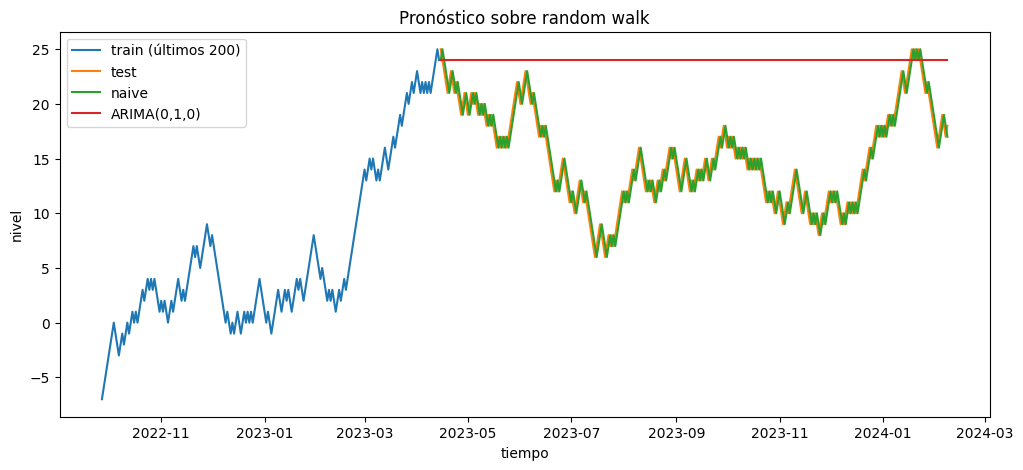

In [8]:
plt.figure(figsize=(12,5))
plt.plot(train.iloc[-200:], label='train (últimos 200)')
plt.plot(test, label='test')
plt.plot(naive_pred, label='naive')
plt.plot(results[(0,1,0)]['fc'], label='ARIMA(0,1,0)')
plt.title('Pronóstico sobre random walk')
plt.xlabel('tiempo')
plt.ylabel('nivel')
plt.legend()
plt.show()


## 5) Conclusión cuantitativa: ARIMA no puede predecir la moneda

Si el proceso es un random walk puro:
- El mejor pronóstico (MSE) a 1 paso es el último valor (naive).
- ARIMA(0,1,0) básicamente reproduce ese pronóstico.
- Modelos más complejos suelen **no mejorar** y muchas veces empeoran por sobreajuste.


In [9]:
rows = []
rows.append(('naive', mse_naive, mae_naive))
for order, v in results.items():
    rows.append((f'ARIMA{order}', v['mse'], v['mae']))

summary = pd.DataFrame(rows, columns=['model','MSE_test','MAE_test']).sort_values('MSE_test')
summary

,model,MSE_test,MAE_test
0,naive,1.000000,1.000000
3,"ARIMA(0, 1, 1)",99.923016,9.017124
2,"ARIMA(1, 1, 0)",99.927791,9.017373
4,"ARIMA(1, 1, 1)",100.101606,9.026455
1,"ARIMA(0, 1, 0)",100.233333,9.033333


In [10]:
# Para pasos ±1, el error a 1 paso del naive tiene MSE ~ 1.
# Si un modelo "predijera" la moneda, veríamos MSE significativamente menor de forma estable.

print('MSE naive:', mse_naive)
for order, v in results.items():
    print(f"MSE ARIMA{order}: {v['mse']}")


MSE naive: 1.0
MSE ARIMA(0, 1, 0): 100.23333333333333
MSE ARIMA(1, 1, 0): 99.92779057314556
MSE ARIMA(0, 1, 1): 99.92301613611892
MSE ARIMA(1, 1, 1): 100.1016059371322


### Extra: experimento de repetición

Repetimos varias simulaciones y medimos el **ratio** `MSE_ARIMA / MSE_naive`.

Si ARIMA realmente “predijera” la moneda, ese ratio sería sistemáticamente < 1. En un random walk puro, el ratio fluctúa alrededor de 1.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/st

ratio mean: 92.97194672152663
ratio std : 100.71462864833005


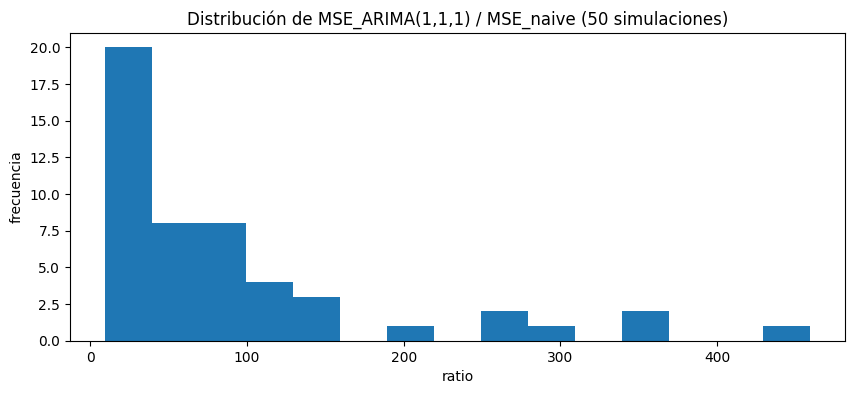

In [11]:
def one_run(n=1200, h=200, seed=None, order=(1,1,1)):
    if seed is not None:
        np.random.seed(seed)
    steps = np.where(np.random.rand(n) < 0.5, -1, 1)
    s = pd.Series(steps.cumsum().astype(float))
    train = s.iloc[:-h]
    test = s.iloc[-h:]
    naive = test.shift(1)
    naive.iloc[0] = train.iloc[-1]
    mse_naive = float(np.mean((test.values - naive.values)**2))

    res = ARIMA(train, order=order).fit()
    fc = res.forecast(steps=h)
    mse_arima = float(np.mean((test.values - fc.values)**2))
    return mse_arima / mse_naive

ratios = [one_run(seed=1000+i, order=(1,1,1)) for i in range(50)]
ratios = np.array(ratios)

print('ratio mean:', ratios.mean())
print('ratio std :', ratios.std())

plt.figure(figsize=(10,4))
plt.hist(ratios, bins=15)
plt.title('Distribución de MSE_ARIMA(1,1,1) / MSE_naive (50 simulaciones)')
plt.xlabel('ratio')
plt.ylabel('frecuencia')
plt.show()


## Mensaje final

ARIMA puede modelar **dependencias temporales** y estructuras en los datos. Pero si la serie se genera como random walk por una moneda justa, **no existe señal predecible** en los incrementos.

En ese caso, el mejor pronóstico a 1 paso (MSE) es simplemente el último valor observado (naive), y ARIMA no puede superar eso de forma estable.
